In [122]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import random

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Complex_ms\Big_statistics\Sobol\..


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [123]:
from SALib.sample import saltelli
from SALib.analyze import sobol
import numpy as np
from tqdm import tqdm

def generate_Sobol(problem, phase_method, N=1024):

    # 1. Генерация выборки (с взаимодействиями)
    param_values = saltelli.sample(problem, N, calc_second_order=True)

    Y = np.zeros(len(param_values))  # быстрее и стабильнее

    for i, p in enumerate(tqdm(param_values, desc=f"Sobol {phase_method.__name__}", unit=" шаг")):
        
        phase_real, fs_mult, duration_T, bits, SNR = p

        F = 400e3
        gen_unstable = 1

        duration = duration_T / F
        fs = F * fs_mult

        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)

        phase_mes = phase_method(t, U, I, F)

        phase_error = abs(phase_mes) - abs(phase_real)

        Y[i] = abs(phase_error)

    # 2. Анализ Sobol (ВАЖНО: тот же флаг!)
    Si = sobol.analyze(problem, Y, calc_second_order=True)

    return Si

In [124]:
import os
import pickle
import hashlib
import numpy as np


def compute_hash_from_Si(Si):
    """Хешируем сами результаты (так как param_values у тебя не сохраняются)"""
    data_bytes = b''

    for key in ['S1', 'ST', 'S2']:
        if key in Si and Si[key] is not None:
            data_bytes += np.array(Si[key]).tobytes()

    return hashlib.md5(data_bytes).hexdigest()


def save_sobol_results(filename, results):
    # если файла нет — просто сохраняем
    if not os.path.exists(filename):
        with open(filename, "wb") as f:
            pickle.dump(results, f)
        print("Создан новый файл с результатами")
        return

    # загружаем существующие данные
    with open(filename, "rb") as f:
        existing_results = pickle.load(f)

    # собираем существующие хеши
    existing_hashes = set()

    for method, Si in existing_results.items():
        h = compute_hash_from_Si(Si)
        existing_hashes.add((method, h))

    # добавляем только новые
    added = False

    for method, Si in results.items():
        h = compute_hash_from_Si(Si)

        if (method, h) in existing_hashes:
            print(f"[{method}] пропущено (дубликат)")
            continue

        existing_results[method] = Si
        print(f"[{method}] добавлено")
        added = True

    if added:
        with open(filename, "wb") as f:
            pickle.dump(existing_results, f)

def load_sobol_results(filename):
    import os

    if not os.path.exists(filename):
        print("Файл не найден")
        return {}

    with open(filename, "rb") as f:
        results = pickle.load(f)

    print("Данные загружены")
    return results

In [125]:
phase_methods = [
    md.get_phase_MP,
    md.get_phase_ZCRR,
    md.get_phase_FFT,
    md.get_phase_HB,
    md.get_phase_XCOR,
    md.get_phase_LI,
    md.get_phase_SWFR
]
# 1) Определяем параметры
problem = {
    'num_vars': 5,
    'names': ['φ', 'FsM','DT','Bit', 'SNR'], #: ['F', 'φ', 'FsM','DT','GU','Bit']
    'bounds': [
        #[300e3, 500e3],     # F
        [1,179],             # phase
        [3, 20],            # fs_mult
        [2, 200],           # duration_T
        #[0.01,10],             # generator instability
        [5,35],                  #bits
        [30,100]                  #SNR dB
    ]
}

In [126]:
results = {} 
for method in phase_methods: 
    Si = generate_Sobol(problem, method, N=8192) 
    results[method.__name__] = Si

C:\Users\Артем\AppData\Local\Temp\ipykernel_20432\2594479874.py:9: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)
Sobol get_phase_SWFR: 100%|██████████| 98304/98304 [00:46<00:00, 2100.57 шаг/s]


In [134]:
save_sobol_results("sobol.pkl", results)
results = load_sobol_results("sobol.pkl")

Создан новый файл с результатами
Данные загружены


In [135]:
def print_sobol_results(results, problem):
    names = problem['names']

    for method, Si in results.items():
        print(f"\n=== {method} ===")

        S1 = Si.get('S1')
        ST = Si.get('ST')
        S2 = Si.get('S2')

        S1_conf = Si.get('S1_conf', np.zeros_like(S1))
        ST_conf = Si.get('ST_conf', np.zeros_like(ST))

        print("\nS1 (первый порядок):")
        for i, name in enumerate(names):
            print(f"{name:>6}: {S1[i]:.4f} ± {S1_conf[i]:.4f}")

        print("\nST (полный эффект):")
        for i, name in enumerate(names):
            print(f"{name:>6}: {ST[i]:.4f} ± {ST_conf[i]:.4f}")

        if S2 is not None:
            print("\nS2 (взаимодействия):")
            for i in range(len(names)):
                for j in range(i+1, len(names)):
                    print(f"{names[i]}-{names[j]}: {S2[i, j]:.4f}")

In [136]:
print_sobol_results (results, problem)


=== get_phase_MP ===

S1 (первый порядок):
     φ: -0.0032 ± 0.0110
   FsM: 0.2289 ± 0.1324
    DT: -0.0029 ± 0.0052
   Bit: 0.0078 ± 0.0048
   SNR: 0.0006 ± 0.0039

ST (полный эффект):
     φ: 0.6412 ± 0.1895
   FsM: 0.8417 ± 0.2198
    DT: 0.0661 ± 0.0580
   Bit: 0.0286 ± 0.0096
   SNR: 0.0357 ± 0.0353

S2 (взаимодействия):
φ-FsM: 0.4532
φ-DT: 0.0054
φ-Bit: 0.0041
φ-SNR: 0.0037
FsM-DT: -0.0426
FsM-Bit: -0.0435
FsM-SNR: -0.0493
DT-Bit: 0.0015
DT-SNR: 0.0057
Bit-SNR: -0.0003

=== get_phase_ZCRR ===

S1 (первый порядок):
     φ: 0.0144 ± 0.0155
   FsM: 0.6546 ± 0.0866
    DT: -0.0028 ± 0.0100
   Bit: 0.0035 ± 0.0029
   SNR: -0.0003 ± 0.0020

ST (полный эффект):
     φ: 0.3385 ± 0.0697
   FsM: 0.9973 ± 0.0624
    DT: 0.6864 ± 1.2370
   Bit: 0.0134 ± 0.0037
   SNR: 0.0066 ± 0.0035

S2 (взаимодействия):
φ-FsM: 0.2966
φ-DT: -0.0046
φ-Bit: -0.0091
φ-SNR: -0.0088
FsM-DT: 0.0623
FsM-Bit: 0.0261
FsM-SNR: 0.0229
DT-Bit: 0.0002
DT-SNR: -0.0009
Bit-SNR: 0.0001

=== get_phase_FFT ===

S1 (первый п

In [130]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_from_results(results, problem):
    names = problem['names']

    methods = list(results.keys())
    all_Si = list(results.values())

    n = len(all_Si)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, (method_name, Si) in enumerate(zip(methods, all_Si)):
        x = np.arange(len(names))
        width = 0.35

        ax = axes[i]

        # Ч/б стиль для журнала
        ax.bar(x - width/2, Si['S1'], width,
               label='S1', color='white', edgecolor='black', hatch='///')
        ax.bar(x + width/2, Si['ST'], width,
               label='ST', color='gray', edgecolor='black', hatch='\\\\\\')

        ax.set_xticks(x)
        # Увеличиваем шрифт меток на оси X (названия переменных)
        ax.set_xticklabels(names, fontsize=14)
        
        # Увеличиваем шрифт меток на оси Y (числа 0.0, 0.2 и т.д.)
        ax.tick_params(axis='y', labelsize=14)
        #ax.set_ylabel('Sobol index')
        method_name=method_name.replace("get_phase_","")
        ax.set_title(method_name, fontsize=16)
        ax.legend()
        ax.grid(True)

    # удалить пустые графики
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

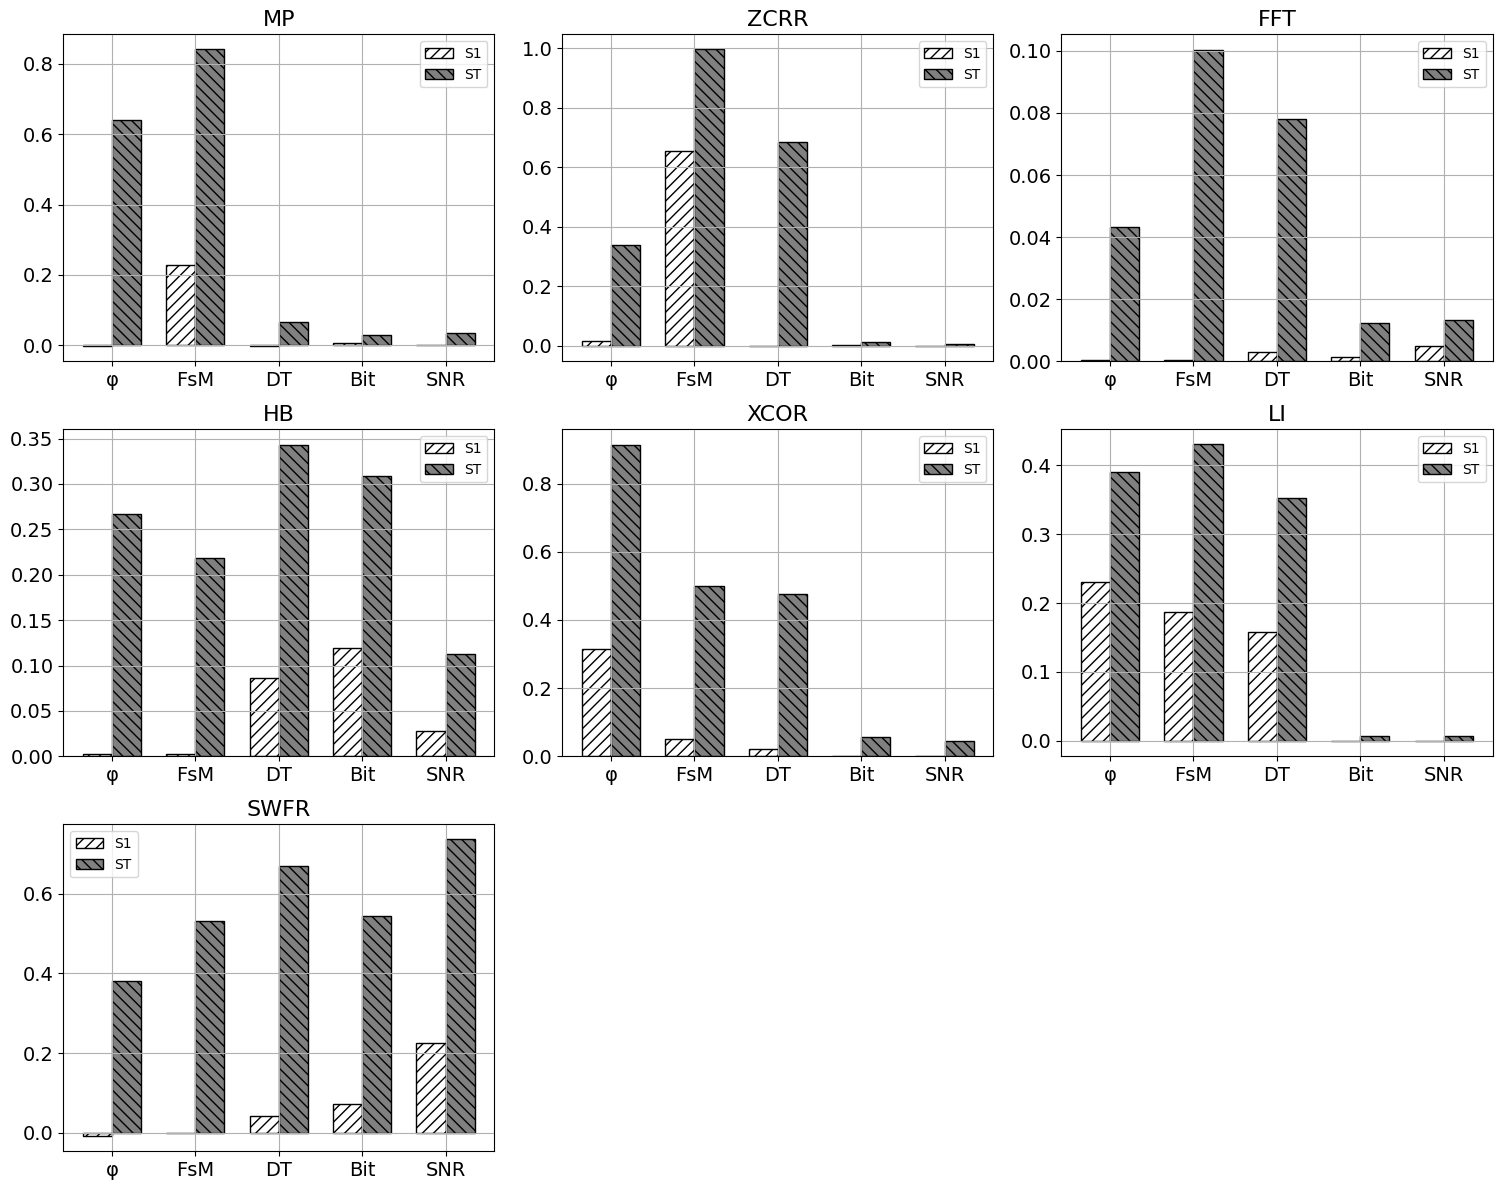

In [131]:
plot_from_results(results, problem)

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_s2_all_methods(results, problem, n_cols=3):
    names = problem['names']
    methods = list(results.keys())

    n_methods = len(methods)
    n_rows = math.ceil(n_methods / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, method_name in enumerate(methods):
        Si = results[method_name]
        S2 = Si['S2']

        ax = axes[i]

        sns.heatmap(
            S2,
            annot=True,
            fmt=".2f",
            xticklabels=names,
            yticklabels=names,
            cmap="viridis",
            ax=ax,
            cbar=False  # чтобы не было 10 colorbar'ов
        )

        ax.set_title(method_name, fontsize=10)

    # удалить пустые графики
    for j in range(n_methods, len(axes)):
        fig.delaxes(axes[j])

    # один общий colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=1)
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

C:\Users\Артем\AppData\Local\Temp\ipykernel_20432\2350045646.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


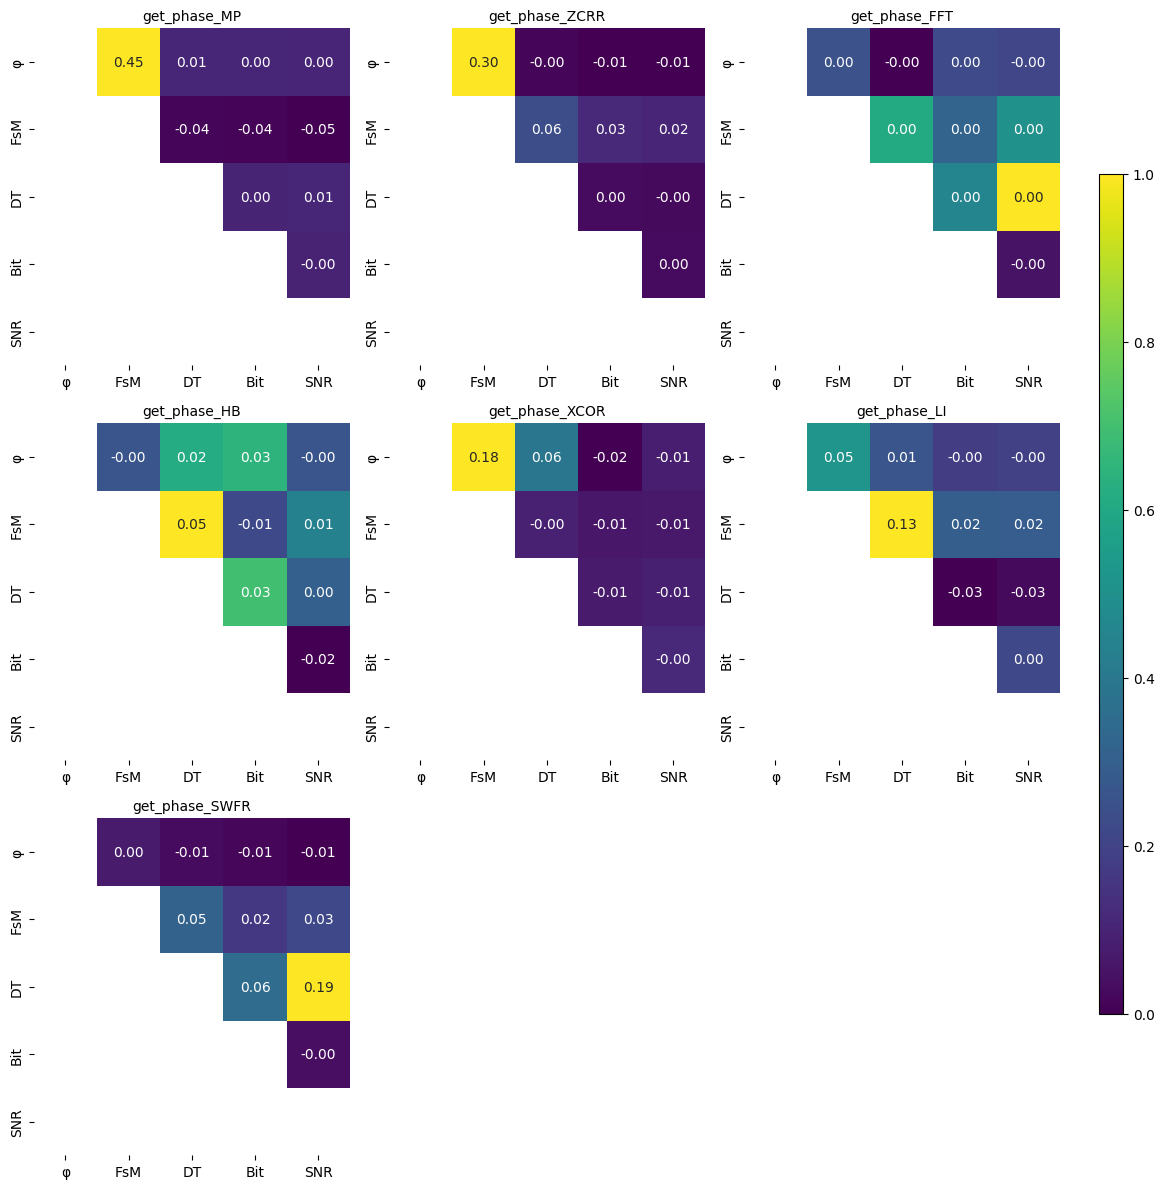

In [133]:
plot_s2_all_methods(results, problem)